<a href="https://colab.research.google.com/github/developer-amna/Generative-AI/blob/main/AI_Agent_Master_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run this in Colab
!pip install -q langgraph langchain langchain-groq langchain-community duckduckgo-search gradio requests ddgs pyowm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 49.5 MB/s eta 0:00:00


In [ ]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_community.tools import DuckDuckGoSearchRun
from google.colab import userdata

In [ ]:
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

In [ ]:
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3
)

In [ ]:
search = DuckDuckGoSearchRun()

In [ ]:
class ResearchState(TypedDict):
    query: str          # User's question
    search_results: str # Raw results from DuckDuckGo
    summary: str        # Final answer from LLM

In [ ]:
def search_node(state: ResearchState) -> ResearchState:
    """Fetch web results for the query."""
    results = search.run(state["query"])
    return {"search_results": results}

In [ ]:
def summarize_node(state: ResearchState) -> ResearchState:
    """Ask LLM to summarize search results into a clear answer."""
    prompt = f"""You are a research assistant. Based on the search results below,
answer the user's question clearly and concisely.

Question: {state["query"]}

Search Results:
{state["search_results"]}

Provide a clear, factual answer in 3-5 sentences."""

    response = llm.invoke(prompt)
    return {"summary": response.content}

In [ ]:
graph = StateGraph(ResearchState)

graph.add_node("search", search_node)
graph.add_node("summarize", summarize_node)

In [ ]:

graph.add_edge(START, "search")
graph.add_edge("search", "summarize")
graph.add_edge("summarize", END)

In [ ]:
agent = graph.compile()

In [ ]:
def run_agent(query: str) -> str:
    result = agent.invoke({"query": query})
    return result["summary"]

In [ ]:
answer = run_agent("What is LangGraph and how does it work?")
print(answer)

LangGraph is an open-source framework from LangChain that enables users to build and manage complex AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex interactions more structured and efficient. LangGraph is a Python library that helps design, visualize, and control multi-step AI workflows, replacing rigid processes with flexible visual graphs. Each node in LangGraph represents a computational step, such as a large language model (LLM), and can be connected to other nodes to form a complete application.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 23.3 MB/s eta 0:00:00


In [ ]:
import os
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
import requests
from google.colab import userdata

# from langchain_community.utilities import OpenWeatherMapAPIWrapper

In [ ]:
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
# os.environ["OPENWEATHERMAP_API_KEY"] = userdata.get("WEATHER_API_KEY")

In [ ]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [ ]:
search_tool = DuckDuckGoSearchRun()
# weather_api = OpenWeatherMapAPIWrapper()

In [ ]:
# weather_api.run('Karachi')

In [ ]:
search_tool.run("Ai Agents")

'AI textbooks define artificial intelligence as the "study and design of intelligent agents," emphasizing that goal-directed behavior is central to intelligence. Discover, use and build agents to create your personal AI agent team. Sign up for free. Create AI agents you can trust with Rasa’s powerful platform, designed to scale, customize, and support real business needs across channels. Want to see Maya Murad explain more about AI Agents? GitHub CopilotWrite better code with AI. GitHub SparkBuild and deploy intelligent apps. GitHub ModelsManage and compare prompts.e2b-dev/awesome-ai-agents.'

In [ ]:
@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """Perform basic arithmetic. Operations: add, sub, mul, div"""
    ops = {"add": first_num + second_num, "sub": first_num - second_num,
           "mul": first_num * second_num}
    if operation == "div":
        return {"result": "Division by zero" if second_num == 0 else first_num / second_num}
    return {"result": ops.get(operation, f"Unknown operation: {operation}")}

In [ ]:
from langchain.tools import tool

@tool
def search(query: str) -> str:
    """Search the web for real-time information."""
    return DuckDuckGoSearchRun().run(query)

In [ ]:
@tool
def get_stock_price(symbol: str) -> dict:
    """Fetch latest stock price for a symbol like AAPL or TSLA."""
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={userdata.get('STOCKS_API_KEY')}"
    return requests.get(url).json()

In [ ]:
tools = [search_tool, calculator, get_stock_price]

In [ ]:
llm_with_tools = llm.bind_tools(tools)

In [ ]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [ ]:
tool_node = ToolNode(tools)

In [ ]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")
agent = graph.compile()

In [ ]:
def run_agent(query: str) -> str:
    result = agent.invoke({"messages": [HumanMessage(content=query)]})
    return result["messages"][-1].content

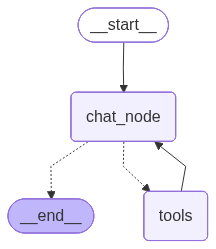

In [ ]:
agent

In [ ]:
run_agent("First find out the stock price of apple using get stock price tool then use price toll then use the calcultor tool to find out how much will it take to purcahse 50 shares? ")


'It would take approximately $8212.50 to purchase 50 shares of Apple stock.'

In [ ]:
run_agent("Explain me AI agents")

"AI agents are software programs that use artificial intelligence (AI) and machine learning (ML) algorithms to interact with their environment, make decisions, and perform tasks autonomously. They can be thought of as virtual entities that can perceive, reason, act, and learn from their surroundings.\n\nAI agents can be categorized into different types based on their capabilities, goals, and behaviors. Here are some common types of AI agents:\n\n1. **Reactive Agents**: These agents respond to their environment based on their current state and the current input. They do not have any memory or knowledge of the past.\n2. **Limited Memory Agents**: These agents can store some information about their past experiences and use it to make decisions.\n3. **Model-Based Agents**: These agents build an internal model of their environment and use it to plan and make decisions.\n4. **Goal-Based Agents**: These agents have a specific goal or objective and use their environment and knowledge to achiev